# Age Estimation and Gender Classification

In this assignment, you will train CNN models to estimate a person's age and predict their gender based on face images. Please read carefully all the instructions before you start to write your code.

**Your Tasks**

You are supposed to train two CNN models.
- Model A: Train a CNN model from scratch, following a few restrictions. Save this model as `age_gender_A.keras`
- Model B: Fine-tune a pre-trained model to perform the same task. Save this model as `age_gender_B.keras`

**Dataset**

Your models will be trained and validated on a folder `train_val/` containing 5,000 labeled face images (size: 128 x 128), originated from the UTKFace dataset. During the assessment phase, your code will be tested on unseen test data.

**Performance Metric**

The evaluation of your models on the test set will be based on the following metrics:
- age estimation: - Mean Absolute Error (MAE)
- gender prediction: accuracy

**GPU Time Management**

Please use the available GPU time wisely, as there are some limitations on free GPU usage. It is said the users can use up to 12 hours in row in Google Colab. But many people found they reached its limit far less than 12 hours. To minimize the risk of reaching the limit, consider the following suggestions:
1. Ensure you have a stable internet connection.
2. Carefully validate your hyperparameters before starting the training process.
3. Based on past experience, each model should be trained in less than 2 hours. If the training time is significantly longer, you may need to adjust your model architecture.


## Setting Up: Mount the google drive
Mount your google drive to the notebook. Also don't forget to **enable GPU** before your training.


In [1]:
#
# Add your code here
#

## Visualize a few photos
It's always beneficial to thoroughly understand your data before beginning the training process. To get a first-hand impression of the dataset, please display a minimum of 20 images from the `train_val/` folder, along with their corresponding age and gender labels. This will help you gain initial insights into the dataset.

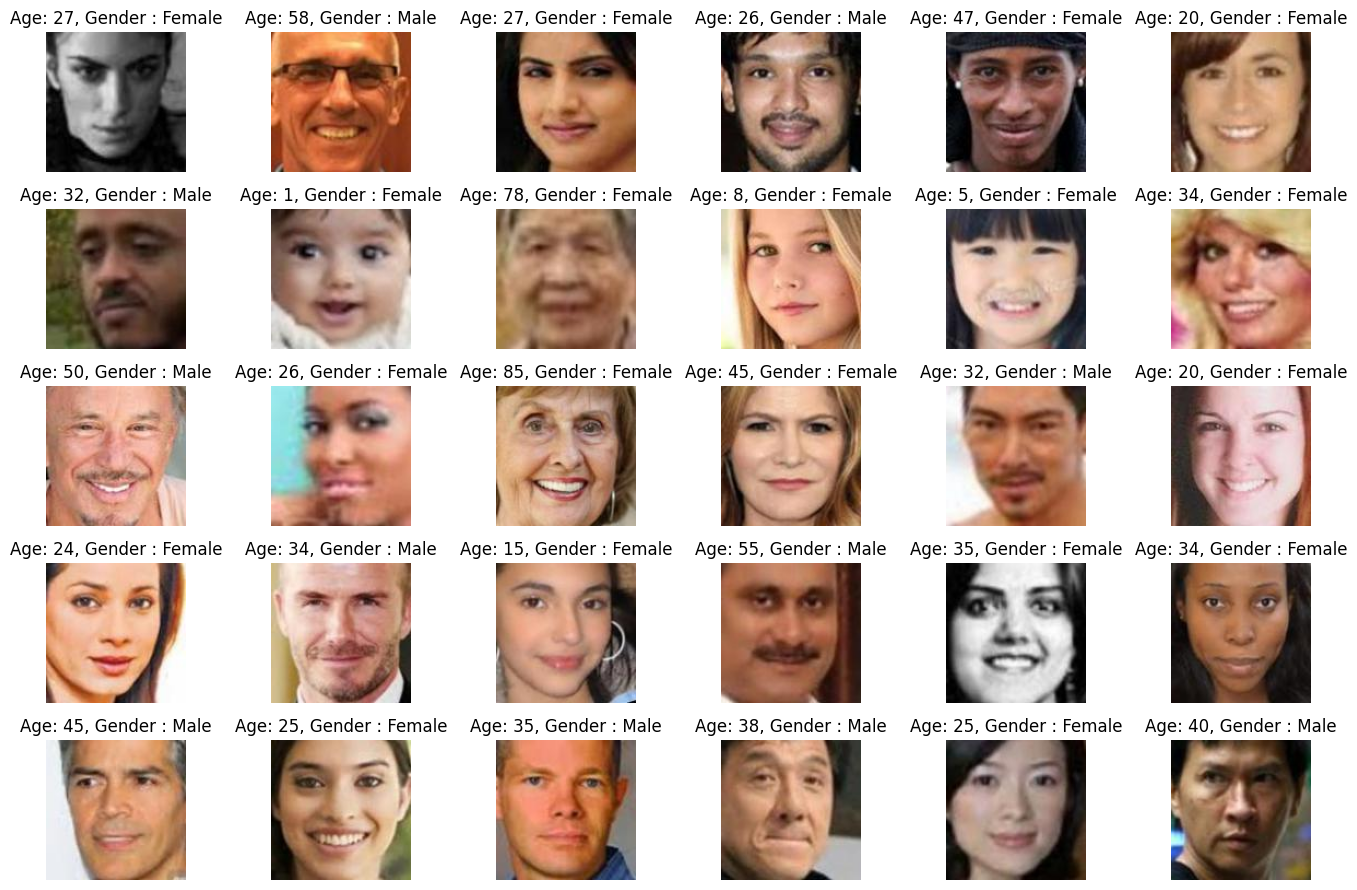

In [ ]:
#
# Add your code here
#
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

folder = "train_val"

images = [f for f in os.listdir(folder) if f.endswith(".jpg")]

#print(images)

plt.figure(figsize=(14,9))

#Print 30 images
for i in range(30):
    img_name = random.choice(images)
    img_path = os.path.join(folder, img_name)

    #Find image age and gender labels from image
    parts = img_name.split("_")
    age = parts[0]
    gender = parts[1]

    img = Image.open(img_path)

    #Use string for comparison to find correct labels
    if (gender == "0"):
        gender_label = "Male"
    else:
        gender_label = "Female"

    #Plot labelled images
    plt.subplot(5,6,i+1)
    plt.imshow(img)
    plt.title(f"Age: {age}, Gender : {gender_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 1: Data Pre-Processing
In this step, you will perform necessary pre-processing tasks before feeding the data into a CNN. The pre-processing includes:

1. Splitting the data into training and validation sets.
2. Loading image data, gender labels and age values, and rescaling pixel values (originally integers between 0 and 255) to the range [0, 1].
3. Data augmentation

The first two pre-processing steps have already been completed for you. Your task in this step is limited to:

3. Data augmentation

Please note:

- Do not modify any part of the provided code except the section marked with ########.
- Do not rescale the age values to the range [0,1], as the original values are used during the testing stage. Rescaling them would significantly impact testing performance.



Number of images for training: 4000
Number of images for validation: 1000
load all image data, age and gender labels...
load all image data, age and gender labels...
Augmenting Data


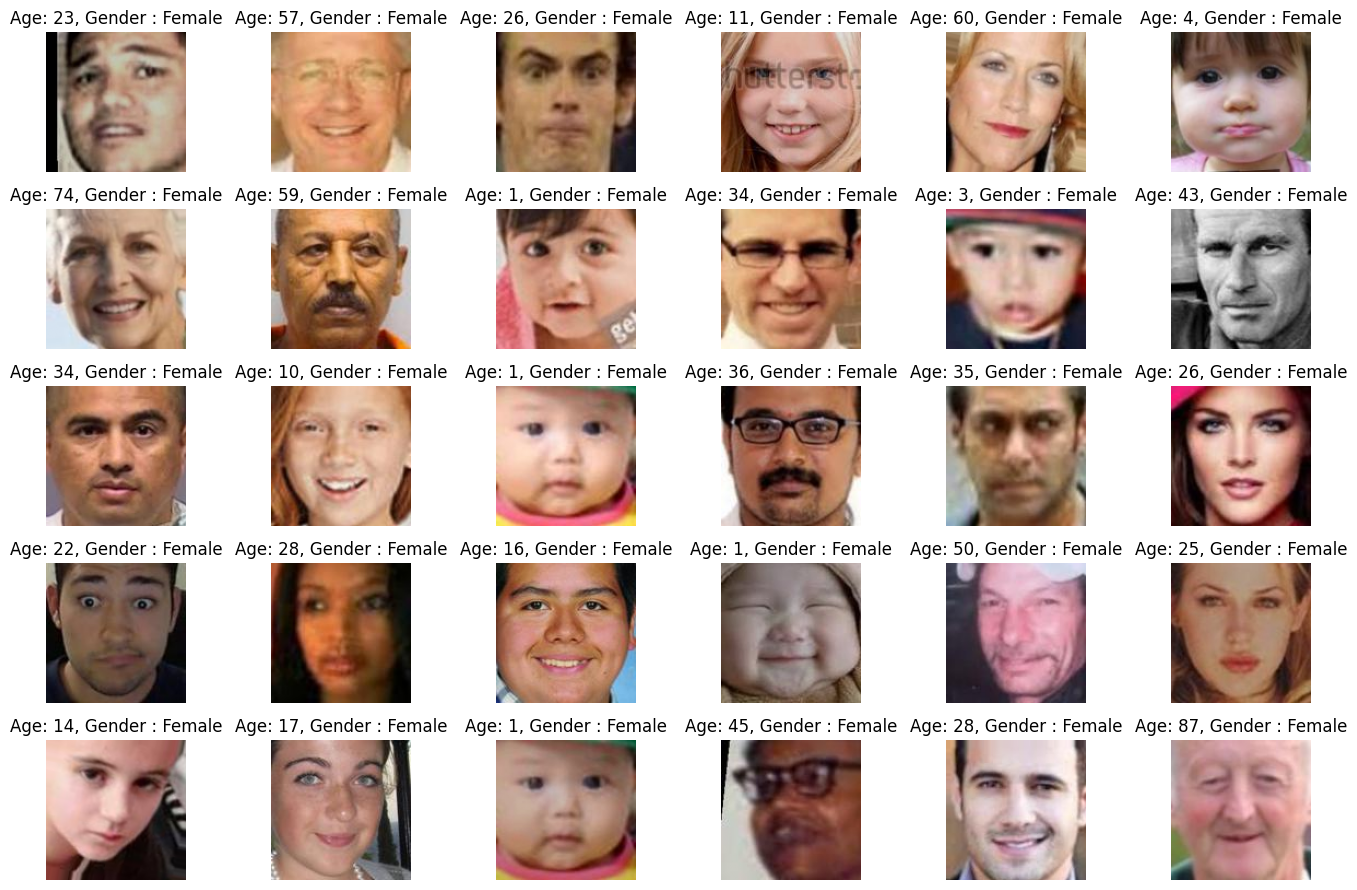

In [ ]:
import os
import random
import numpy as np
import cv2


folder_train_val = "train_val" ####### the path for the train_val/ folder #######
all_image_files = [file for file in os.listdir(folder_train_val) if file.lower().endswith(('.jpg'))]

# Shuffle the dataset to ensure random distribution
random.seed(0)  # Ensure reproducibility
random.shuffle(all_image_files)

# Calculate the number of images for each set
n_train_val = len(all_image_files)
train_end = int(n_train_val * 0.8)

# Split the dataset
train_image_files = all_image_files[:train_end]
val_image_files = all_image_files[train_end:]
print(f"Number of images for training: {len(train_image_files)}")
print(f"Number of images for validation: {len(val_image_files)}")

def load_imgs_lables(dataset_path,filenames):
  print('load all image data, age and gender labels...')
  images = []
  age_labels = []
  gender_labels = []
  for current_file_name in filenames:
    img = cv2.imread(os.path.join(dataset_path, current_file_name))
    img = img / 255.0  # Normalize pixel values
    labels = current_file_name.split('_')
    age_label = int(labels[0])
    gender_label = int(labels[1])
    age_labels.append(age_label)
    gender_labels.append(gender_label)
    images.append(img)

  # Convert to NumPy arrays
  images = np.array(images)
  age_labels = np.array(age_labels)
  gender_labels = np.array(gender_labels)
  return images, age_labels, gender_labels

# load data from the training set
train_images, train_age, train_gender = load_imgs_lables(folder_train_val,train_image_files)

# load data from the validation set
val_images, val_age, val_gender = load_imgs_lables(folder_train_val,val_image_files)

#
######### Add your code for data augmentation here #########
#
import tensorflow as tf
from tensorflow.keras import Sequential, layers


def augment_data(images, age_labels, gender_labels):

  #Initialize empty augmented data lists
  augmented_images = []
  age_list = []
  gender_list = []

  #Find total number of images
  num_images = len(images)

  print("Augmenting Data")

  #Loop through all images
  for i in range(num_images):
    img = images[i]
    age = age_labels[i]
    gender = gender_labels[i]

    #Add each base image to augmented images
    augmented_images.append(img)
    age_list.append(age)
    gender_list.append(gender)

    #Horizontal flipping
    flipped_img = cv2.flip(img, 1)
    augmented_images.append(flipped_img)
    age_list.append(age)
    gender_list.append(gender)

    #Rotations
    #Do small +- 15 degree image rotations to approx 50% of images
    if random.random() < 0.5:
      angle = random.uniform(-15,15)
      (h, w) = img.shape[:2]
      centre = (w//2, h//2)
      M = cv2.getRotationMatrix2D(centre, angle, 1.0)
      rotated_img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

      #Add rotated images, aswell as appropriate labels to augmented dataset
      augmented_images.append(rotated_img)
      age_list.append(age)
      gender_list.append(gender)

    #Brightness alterations
    #Small brightness alterations to approx 50% of images
    if random.random() < 0.5:
      img_hsv = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2HSV).astype(np.float32)

      brightness_factor = random.uniform(0.7, 1.3)

      #Clip max brightness values
      img_hsv[:, :, 2] = np.clip(img_hsv[:, :, 2] * brightness_factor, 0, 255)

      #Scale appropriately
      bright_img = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
      bright_img = bright_img / 255

      #Add bright altered images, aswell as appropriate labels to augmented dataset
      augmented_images.append(bright_img)
      age_list.append(age)
      gender_list.append(gender)

    #Transformations
    #Small translations to approx 30% of images
    if random.random() < 0.3:
      #Dimensions of image
      (h, w) = img.shape[:2]

      point_1 = np.float32([[10,10], [w-10,10], [10,h-10]])

      #Randomly chosen values to shift by
      shift_x = random.randint(-5,5)
      shift_y = random.randint(-5,5)

      point_2 = np.float32([[10+shift_x, 10+shift_y], [w-10+shift_x, 10+shift_y], [10+shift_x, h-10+shift_y]])

      M = cv2.getAffineTransform(point_1, point_2)

      affine_img = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REPLICATE)

      #Add translated images, aswell as appropriate labels to augmented dataset
      augmented_images.append(affine_img)
      age_list.append(age)
      gender_list.append(gender)

  #Return the augmented dataset
  return np.array(augmented_images), np.array(age_list), np.array(gender_list)

#Set augmented dataset
augmented_images, augmented_age, augmented_gender = augment_data(train_images, train_age, train_gender)

plt.figure(figsize=(14,9))

for i in range(30):
    #Pick random augmented images to display and their labels
    num = random.randint(0, len(train_images)-1)
    img = augmented_images[num]
    age = augmented_age[num]
    gender = augmented_gender[num]  

    if (gender == "0"):
        gender_label = "Male"
    else:
        gender_label = "Female"

    img_rgb = img[...,::-1]

    plt.subplot(5,6,i+1)
    plt.imshow(img_rgb)
    plt.title(f"Age: {age}, Gender : {gender_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#Using tensorflow's inbuilt data augmentation methods

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"), 
    layers.RandomRotation(0.15), 
    layers.RandomZoom(0.1), 
    layers.RandomTranslation(height_factor=0.0, width_factor = 0.1)
    ])

AutoTune = tf.data.AUTOTUNE
Batch_Size = 32

#Function to apply TF data augmentation methods
def augment_data_tf(images, labels):
   images = data_augmentation(images, training = True)
   return images, labels

#Create the train dataset from the TF methods
train_ds = tf.data.Dataset.from_tensor_slices((train_images, {"age_output":train_age, "gender_output":train_gender}))
train_ds = train_ds.shuffle(4000).batch(batch_size=Batch_Size)
train_ds = train_ds.map(augment_data_tf, num_parallel_calls=AutoTune)
train_ds = train_ds.prefetch(AutoTune)

#Create val dataset from TF methods
val_ds = tf.data.Dataset.from_tensor_slices((val_images, {"age_output":val_age, "gender_output":val_gender}))
val_ds = val_ds.batch(batch_size=Batch_Size).prefetch(AutoTune)


## STEP2A: Build your own CNN network
In this step, you will define your own CNN model for identifying gender and predicting age. Although there are two tasks, you only need to build one CNN model with two outputs. You may refer to online resources for solutions.

Here are the key requirements and restrictions for your network:
1.	The input size must be 128 x 128 x 3, which means you **should not resize** the original images. This is because my test code relies on this particular input size. Any other size will cause problem in the testing stage.
2.  Please treat the gender classification as a binary problem, i.e., **the output layer for the gender branch has only 1 unit**, instead of 2. Although it is technically correct to treat gender classification as a multi-class problem with 2 classes, i.e., 2 units in the last layer, the test code only supports a 1-unit last-layer configuration for the gender branch.
3.	The size of feature maps being fed to the first fully connected layer must be less than 10 x 10, while there is no number limitation about the depth.
4.	Incorporate techniques to prevent overfitting as appropriate.

At the end of your implementation, use `modelA.summary()` to display the model architecture and use `plot_model()` to visualize the architecture.

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 64, 64,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_10

 Total params: 4,322,210 (16.49 MB)

 Trainable params: 4,320,290 (16.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

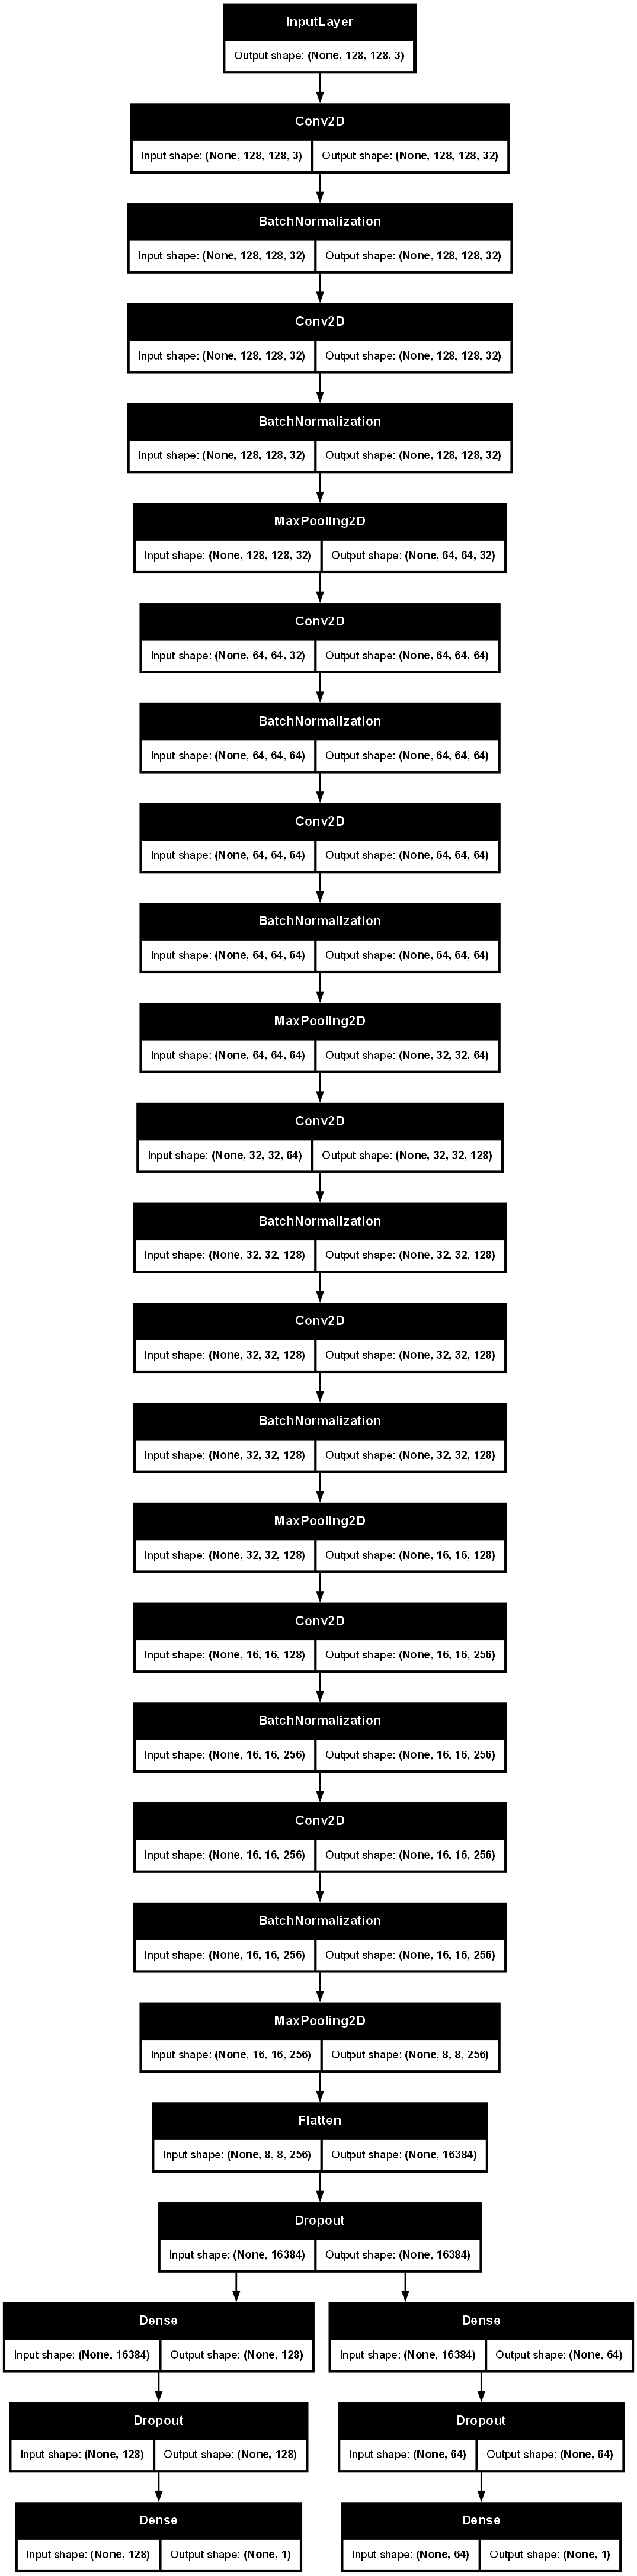

In [ ]:
#
# Add your code here
#

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

#Input image size 128 x 128 RGB as required
input_layer = Input(shape=(128,128,3))

#Create the convolutional layers

#CNN Block 1
x = Conv2D(32, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001))(input_layer)
x = BatchNormalization()(x)
x = Conv2D(32, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x) #Downsample

#CNN Block 2
x = Conv2D(64, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

#CNN Block 3
x = Conv2D(128, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

#CNN Block 4
x = Conv2D(256, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Conv2D(256, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

#Flatten before dense layers
x = Flatten()(x)
x = Dropout(0.5)(x) #Use dropout to prevent overfitting 

#Regression Age Prediction Branch
age_branch = Dense(128, activation="relu", kernel_regularizer=l2(0.001))(x)
age_branch = Dropout(0.3)(age_branch)
age_output = Dense(1, activation="linear", name="age_output")(age_branch)

#Binary Classification Gender Prediction Branch
gender_branch = Dense(64, activation="relu", kernel_regularizer=l2(0.001))(x)
gender_branch = Dropout(0.3)(gender_branch)
gender_output = Dense(1, activation="sigmoid", name="gender_output")(gender_branch)

#Create multi-output model
modelA = Model(inputs=input_layer, outputs = [age_output, gender_output])

modelA.summary()
from tensorflow.keras.utils import plot_model
plot_model(modelA, show_shapes=True,dpi=100)

## STEP3A: Compile and train your model
Compile and train your model here.
Save your model by `modelA.save(your_model_folder+"age_gender_A.keras")` after training.

**DON'T use any other name for your model file.** This is because my test code relies on this particular model name. Any other file name will cause problem in the testing stage.

**Save the model with `save()`** to save the entire model (including a model's architecture, weights, and training configuration) as a `.keras` zip archive. Don't save it with `save_weights()`.


In [ ]:
#
# Add your code here
#

from tensorflow.keras.callbacks import EarlyStopping

#Allows for choosing which Augmented Dataset to use
custom_augmentation = True

#Early stopping to stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True
)

#Compile model with seperate losses and metrics for each output
modelA.compile(optimizer="adam", loss = {
    "age_output" : "mse", #Regression
    "gender_output" : "binary_crossentropy" #Classification
}, metrics = {
    "age_output" : "mae", #Use Mean Absolute Error for age monitoring
    "gender_output" : "accuracy" #Use accuracy for gender monitoring
}
)

#Choose to use model with custom dataset or TF dataset
if custom_augmentation:
    A = modelA.fit(
        augmented_images,
        {
            "age_output" : augmented_age,
            "gender_output" : augmented_gender
        },
        validation_data = (val_images,
                        {
                            "age_output" : val_age,
                            "gender_output" : val_gender
                        }
                        ),
        epochs = 100,
        batch_size = 32,
        callbacks = [early_stop]
    )
#Using TF datasets
else:
    A = modelA.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[early_stop]
    )

#Save trained models
folder_models = "models/"
modelA.save(folder_models+'age_gender_A.keras')

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 194s 507ms/step - age_output_loss: 264.2201 - age_output_mae: 12.2219 - gender_output_accuracy: 0.6968 - gender_output_loss: 0.6028 - loss: 266.1248 - val_age_output_loss: 306.1599 - val_age_output_mae: 14.3294 - val_gender_output_accuracy: 0.7480 - val_gender_output_loss: 0.5504 - val_loss: 310.6299
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 202s 539ms/step - age_output_loss: 166.3506 - age_output_mae: 9.6502 - gender_output_accuracy: 0.7620 - gender_output_loss: 0.4574 - loss: 168.1765 - val_age_output_loss: 129.1436 - val_age_output_mae: 8.4912 - val_gender_output_accuracy: 0.8310 - val_gender_output_loss: 0.3691 - val_loss: 129.8091
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 206s 550ms/step - age_output_loss: 126.5893 - age_output_mae: 8.3927 - gender_output_accuracy: 0.7916 - gender_output_loss: 0.4072 - loss: 128.6994 - val_age_output_loss: 121.9975 - val_age_output_mae: 8.3977 - val_gender_output_accuracy: 0.8360 - val_gender_output_loss: 0.3

## STEP4A: Draw the learning curves
Draw four learning curve figures for model A as follows.
1.	The loss of the gender classification over the training and validation set
2.	The accuracy of the gender classification over the training and validation set
3.	The loss of the age estimation over the training and validation set
4.	The MAE of the age estimation over the training and validation set

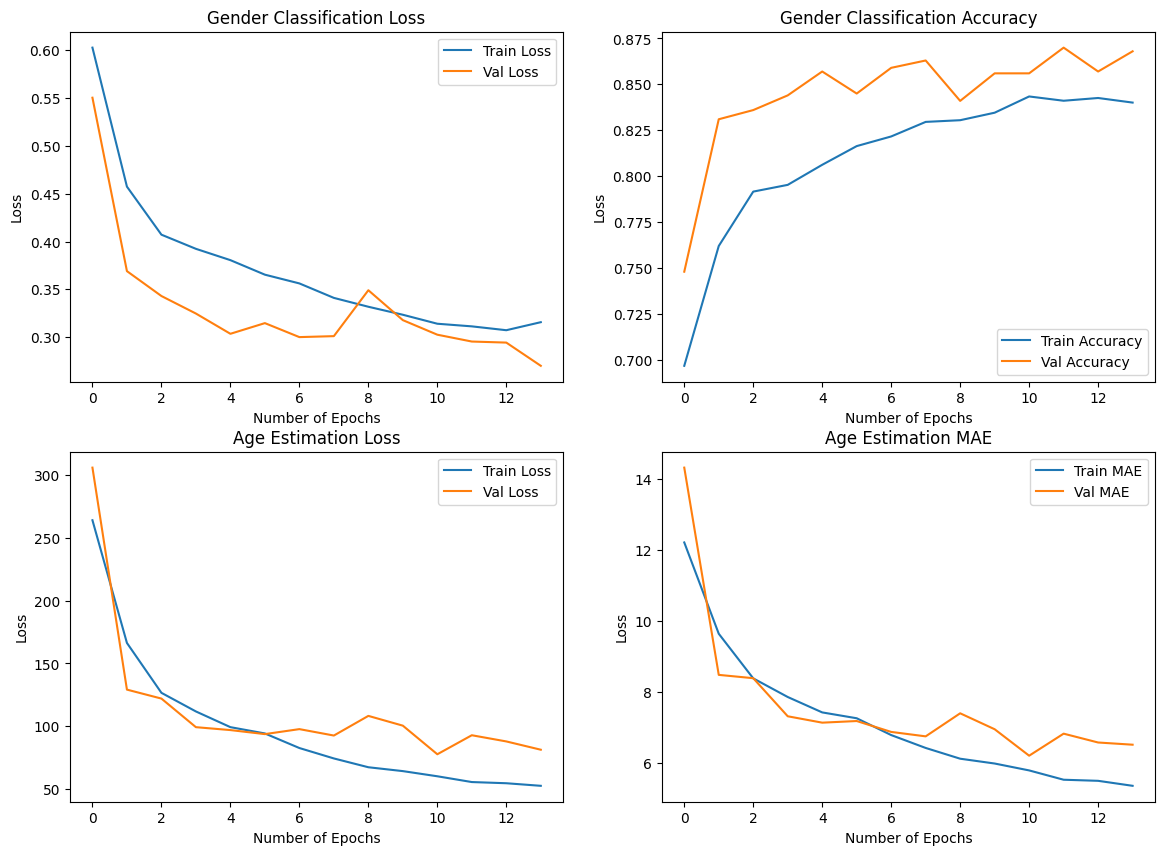

In [ ]:
#
# Add your code here
#
history = A.history

#Plot learning curves

plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.plot(history["gender_output_loss"], label = "Train Loss")
plt.plot(history["val_gender_output_loss"], label = "Val Loss")
plt.title("Gender Classification Loss")
plt.xlabel("Number of Epochs"); plt.ylabel("Loss")
plt.legend()

plt.subplot(2,2,2)
plt.plot(history["gender_output_accuracy"], label = "Train Accuracy")
plt.plot(history["val_gender_output_accuracy"], label = "Val Accuracy")
plt.title("Gender Classification Accuracy")
plt.xlabel("Number of Epochs"); plt.ylabel("Loss")
plt.legend()

plt.subplot(2,2,3)
plt.plot(history["age_output_loss"], label = "Train Loss")
plt.plot(history["val_age_output_loss"], label = "Val Loss")
plt.title("Age Estimation Loss")
plt.xlabel("Number of Epochs"); plt.ylabel("Loss")
plt.legend()

plt.subplot(2,2,4)
plt.plot(history["age_output_mae"], label = "Train MAE")
plt.plot(history["val_age_output_mae"], label = "Val MAE")
plt.title("Age Estimation MAE")
plt.xlabel("Number of Epochs"); plt.ylabel("Loss")
plt.legend()



## STEP2B: Build a CNN network based on a pre-trained model
Choose an existing CNN architecture pre-trained on ImageNet and fine-tune it on this dataset.

As with Model A, **do not resize the input image size**.
Ensure that the output layer for **the gender branch has only 1 unit**.

At the end of the cell, use `modelB.summary()` to display the model architecture and use `plot_model()` to visualize the architecture.


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 128, 128,  │          0 │ input_layer_7[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 128, 128,  │          0 │ rescaling_4[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_0.75_128  │ (None, 4, 4, 768) │  1,832,976 │ rescaling_5[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ mobilenet_0.75_1… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 768)       │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 512)       │    393,728 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 256)       │    131,328 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_11[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │     32,896 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │     16,448 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │        129 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │         65 │ dense_13[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,410,642 (9.20 MB)

 Trainable params: 576,130 (2.20 MB)

 Non-trainable params: 1,834,512 (7.00 MB)

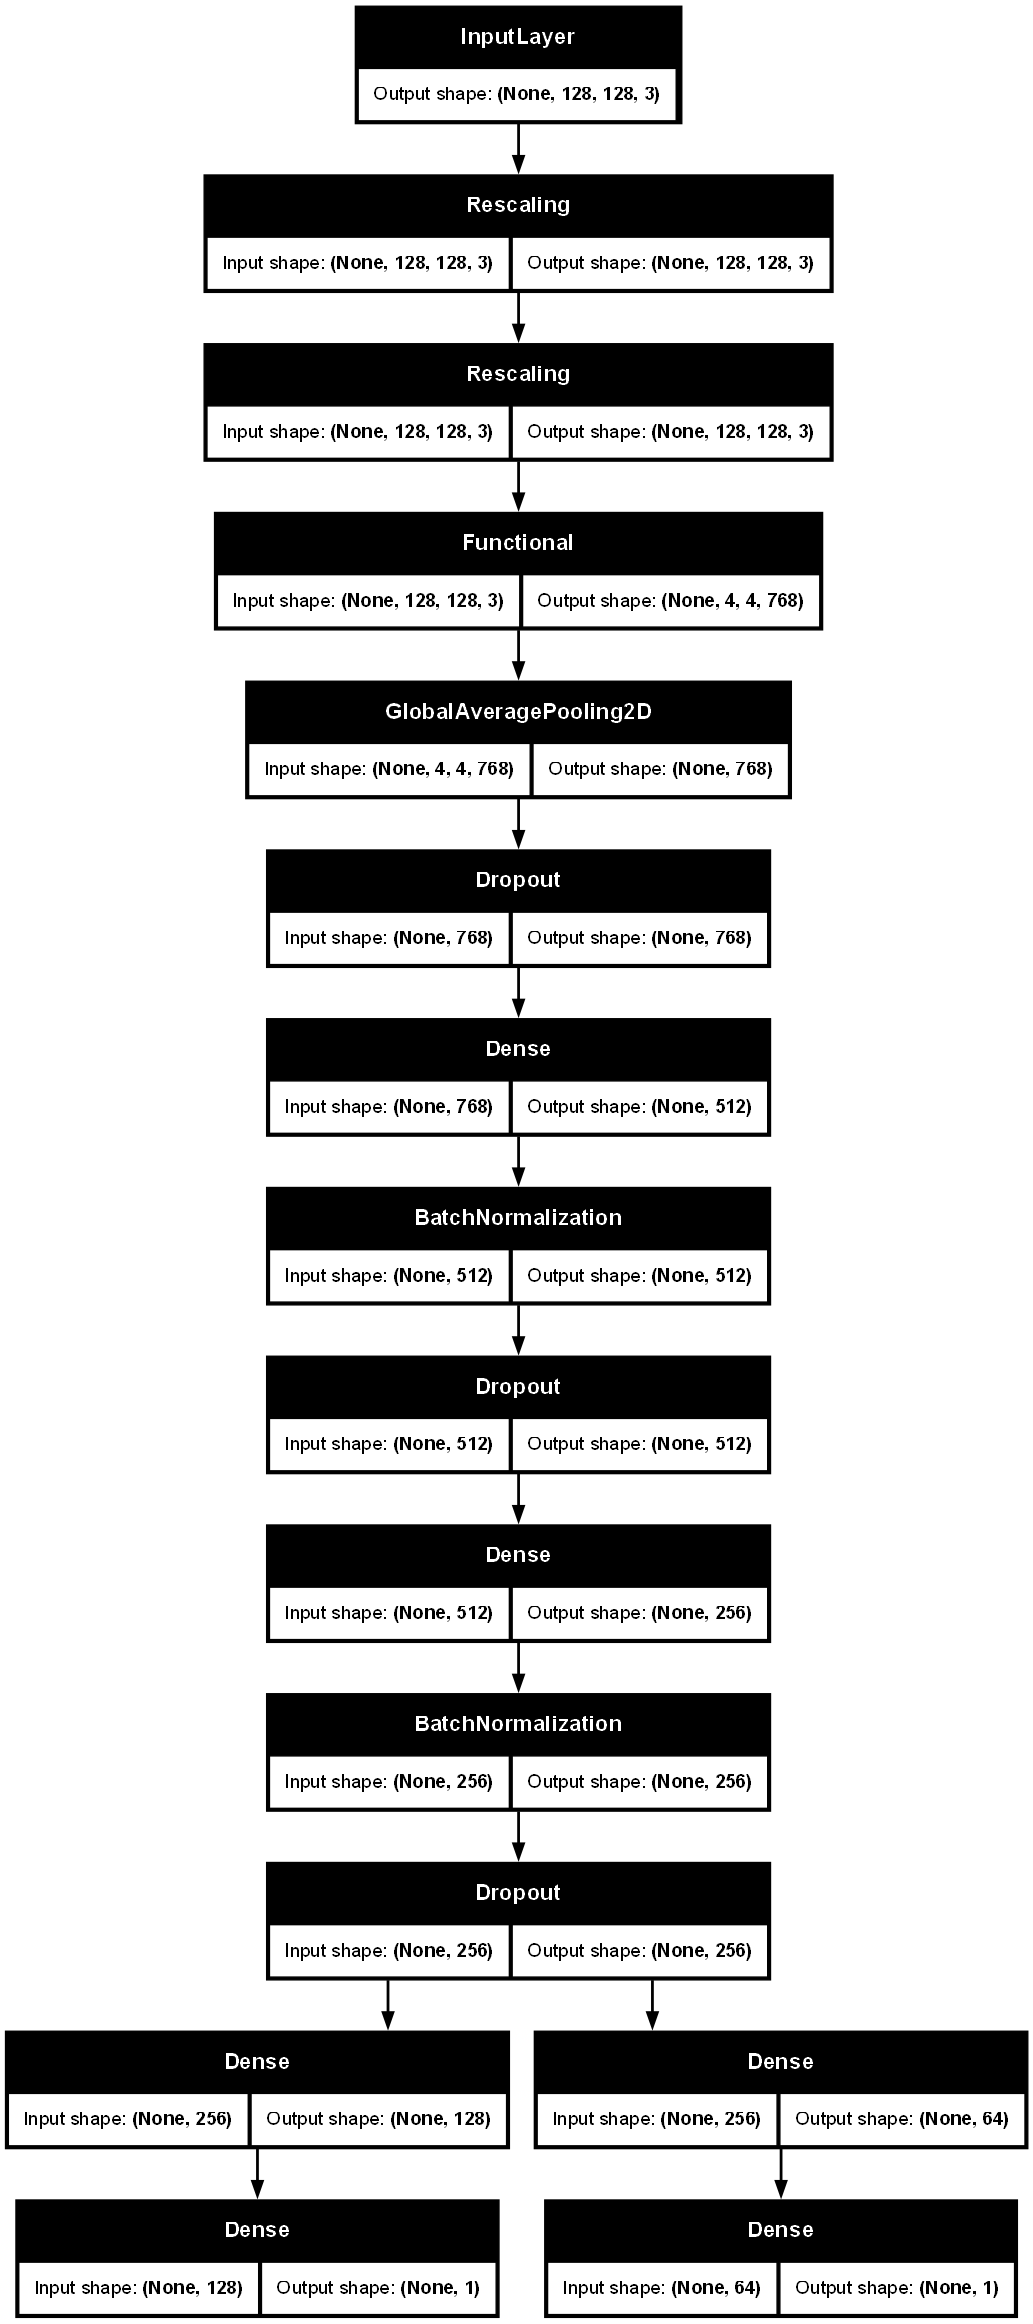

In [ ]:
#
# Add your code here
#

from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Rescaling

#Input image size 128x128 RGB as before
input_layer = Input(shape=(128,128,3))

#L2 regularization constant 
l2_val = 0.001

#Preprocessing and normalization
x = Rescaling(scale=255.0)(input_layer)
x = Rescaling(scale=1./127.5, offset=-1)(x)

#Load MobileNet architecture and freeze layers, alpha=0.75 for a faster network, less chance of overfitting
base_model = MobileNet(input_shape=(128,128,3), include_top=False, weights="imagenet", alpha=0.75)
base_model.trainable = False

#Pass inputs to MobileNet
x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.6)(x)

#Fully connected Layers
#Dense Layer 1
x = Dense(512, activation="relu", kernel_regularizer=l2(l2_val))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

#Dense Layer 2
x = Dense(256, activation="relu", kernel_regularizer=l2(l2_val))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

#Regression Age Prediction Branch
age_branch = Dense(128, activation="relu", kernel_regularizer=l2(0.001))(x)
age_output = Dense(1, activation="linear", name="age_output")(age_branch)

#Binary Classification Gender Prediction Branch
gender_branch = Dense(64, activation="relu", kernel_regularizer=l2(0.001))(x)
gender_output = Dense(1, activation="sigmoid", name="gender_output")(gender_branch)

#Create model
modelB = Model(inputs = input_layer, outputs = [age_output, gender_output])

#Plot model and print architecture
modelB.summary()
from tensorflow.keras.utils import plot_model
plot_model(modelB, show_shapes=True,dpi=100)

## STEP3B: Compile and train your model
Compile and train your model here.
Save your model to `age_gender_B.keras` after training.

**DON'T use any other name for your model file.** This is because my test code relies on this particular model name. Any other file name will cause problem in the testing stage.

**Also, save the model with `save()` instead of `save_weights()`.**


In [ ]:
#
# Add your code here
#

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

#Allows for choosing which Augmented Dataset to use
custom_augmentation = False

#Shows and sets which dataset is used
if custom_augmentation:
    print("Using custom data augmentation")
    train_dataset = (augmented_images, {"age_output":augmented_age, "gender_output":augmented_gender})
else:
    print("Using TF augmented dataset")
    train_dataset = train_ds

#Early stopping to stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 10,
    restore_best_weights = True
)

#Set initial learning rate and optimizer
initial_lr = 3e-4
optimizer = Adam(learning_rate = initial_lr)

#Compile model
modelB.compile(optimizer=optimizer, loss = {
    "age_output" : "mse",
    "gender_output" : "binary_crossentropy"
}, loss_weights = {
    "age_output" : 0.05,
    "gender_output" : 1.0
},
    metrics = {
    "age_output" : "mae",
    "gender_output" : "accuracy"
}
)

#Initial set of training, pre-fine-tuning 
if custom_augmentation:
    B = modelB.fit(
        augmented_images,
        {
            "age_output" : augmented_age,
            "gender_output" : augmented_gender
        },
        validation_data = (val_images,
                        {
                            "age_output" : val_age,
                            "gender_output" : val_gender
                        }
                        ),
        epochs = 10,
        batch_size = 32,
        callbacks = [early_stop]
    )
else:
    B = modelB.fit(
        train_ds,
        validation_data = val_ds,
        epochs = 10,
        callbacks=[early_stop]
    )

#Save pre-fine tuned model
augmentation_type = "custom" if custom_augmentation else "tf"
modelB.save(f"modelB_pre_fine_tune_{augmentation_type}.keras")

#Reload the saved model to safely fine-tune
modelB = tf.keras.models.load_model(f"modelB_pre_fine_tune_{augmentation_type}.keras", safe_mode=False)

base_model = modelB.get_layer("mobilenet_0.75_128")

num_unfrozen = 10
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-num_unfrozen:]:
    layer.trainable = True

modelB.compile(optimizer=tf.keras.optimizers.Adam(1e-6), loss = {
        "age_output" : "mse",
        "gender_output" : "binary_crossentropy"
    }, loss_weights = {
        "age_output" : 0.05,
        "gender_output" : 1.0
    },
        metrics = {
        "age_output" : "mae",
        "gender_output" : "accuracy"
    }
    )    

print(f"Training with last {num_unfrozen} layers unfrozen")

if custom_augmentation:
    B_finetuned = modelB.fit(
        augmented_images,
        {
            "age_output" : augmented_age,
            "gender_output" : augmented_gender
        },
        validation_data = (val_images,
                        {
                            "age_output" : val_age,
                            "gender_output" : val_gender
                        }
                    ),
        epochs = 50,
        batch_size = 32,
        callbacks = [early_stop]
    )
else:
    B_finetuned = modelB.fit(
        train_ds,
        validation_data = val_ds,
        epochs = 50,
        callbacks=[early_stop]
    )

#Save model
your_model_folder = "models/"
modelB.save(your_model_folder+"age_gender_B.keras")
print(f"Saved fine-tuned model using {augmentation_type} augmentation")






Using TF augmented dataset
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - age_output_loss: 114.4702 - age_output_mae: 7.8157 - gender_output_accuracy: 0.7703 - gender_output_loss: 0.4639 - loss: 7.2967 - val_age_output_loss: 181.9483 - val_age_output_mae: 9.6164 - val_gender_output_accuracy: 0.6440 - val_gender_output_loss: 0.8510 - val_loss: 10.9407
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - age_output_loss: 113.3258 - age_output_mae: 7.7596 - gender_output_accuracy: 0.7765 - gender_output_loss: 0.4595 - loss: 7.2288 - val_age_output_loss: 106.4623 - val_age_output_mae: 7.3658 - val_gender_output_accuracy: 0.8420 - val_gender_output_loss: 0.3480 - val_loss: 6.5289
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - age_output_loss: 112.0665 - age_output_mae: 7.7069 - gender_output_accuracy: 0.7870 - gender_output_loss: 0.4443 - loss: 7.1448 - val_age_output_loss: 109.7915 - val_age_output_mae: 7.1275 - val_gender_output_accuracy: 0.8450 - val_gender_output_loss

## STEP4B: Draw the learning curves
Draw four learning curve figures for model B as follows.
1. The loss of the gender classification over the training and validation set
2. The accuracy of the gender classification over the training and validation set
3. The loss of the age estimation over the training and validation set
4. The MAE of the age estimation over the training and validation set

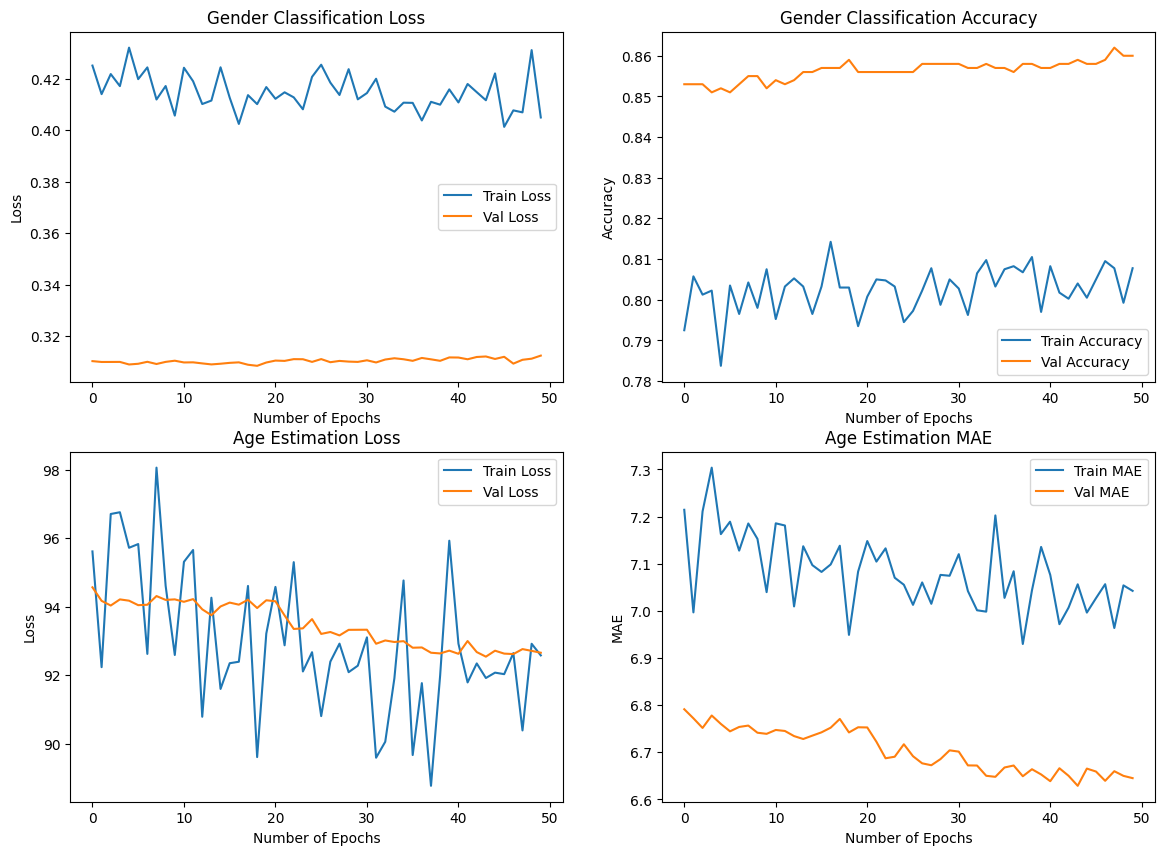

In [26]:
#
# Add your code here
#

history = B_finetuned.history

plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.plot(history["gender_output_loss"], label = "Train Loss")
plt.plot(history["val_gender_output_loss"], label = "Val Loss")
plt.title("Gender Classification Loss")
plt.xlabel("Number of Epochs"); plt.ylabel("Loss")
plt.legend()

plt.subplot(2,2,2)
plt.plot(history["gender_output_accuracy"], label = "Train Accuracy")
plt.plot(history["val_gender_output_accuracy"], label = "Val Accuracy")
plt.title("Gender Classification Accuracy")
plt.xlabel("Number of Epochs"); plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2,2,3)
plt.plot(history["age_output_loss"], label = "Train Loss")
plt.plot(history["val_age_output_loss"], label = "Val Loss")
plt.title("Age Estimation Loss")
plt.xlabel("Number of Epochs"); plt.ylabel("Loss")
plt.legend()

plt.subplot(2,2,4)
plt.plot(history["age_output_mae"], label = "Train MAE")
plt.plot(history["val_age_output_mae"], label = "Val MAE")
plt.title("Age Estimation MAE")
plt.xlabel("Number of Epochs"); plt.ylabel("MAE")
plt.legend()

plt.savefig("ModelB learning Curves")

## STEP5: Evaluate the model on the test set
I will load your two models for testing. The test set will not be available before your submission.

The metrics for measuring the performance on the test set are:
- age estimation: MAE (Mean Absolute Error)
- gender classification: accuracy


In [ ]:
#
# Don't add code in this cell when submitting this file
#